# Etapa 2 — Limpieza y Filtro de Dominancia de Frentes de Pareto

Este notebook:
1. Lee todos los `pareto_front.txt` de los 5 runs por instancia (cdmx, clustering, phub).
2. Combina las soluciones de todas las ejecuciones.
3. Aplica el filtro de dominancia de Pareto (elimina puntos dominados).
4. Deduplica por vector de solución y por objetivo.
5. Guarda el frente limpio por instancia.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from collections import defaultdict

RESULTS_DIR = Path('../frentes_pareto_resultados')
OUTPUT_DIR  = Path('../frentes_pareto_resultados/clean')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DATASETS = {
    #'cdmx'      : RESULTS_DIR / 'cdmx',
    'clustering': RESULTS_DIR / 'clustering',
    #'phub'      : RESULTS_DIR / 'phub_v2',
}

print('✓ Directorios configurados')
for name, path in DATASETS.items():
    n = sum(1 for _ in path.iterdir() if _.is_dir())
    print(f'  {name}: {n} instancias')

✓ Directorios configurados
  clustering: 9 instancias


## 1. Funciones de lectura y filtro

In [2]:
def parse_pareto_front(filepath):
    """
    Lee un pareto_front.txt.

    Formato:
      línea impar : f1 f2   (f1 = -cobertura, f2 = costo)
      línea par   : vector binario de solución

    Devuelve:
      objectives : np.ndarray shape (n, 2)  — [f1, f2]
      solutions  : list de np.ndarray int8  — vectores binarios
    """
    objectives = []
    solutions  = []

    lines = Path(filepath).read_text().strip().splitlines()

    i = 0
    while i < len(lines) - 1:
        obj_line = lines[i].strip()
        sol_line = lines[i + 1].strip()

        if not obj_line or not sol_line:
            i += 1
            continue

        parts = obj_line.split()
        if len(parts) != 2:
            i += 1
            continue

        try:
            f1 = float(parts[0])
            f2 = float(parts[1])
        except ValueError:
            i += 1
            continue

        sol = np.array(sol_line.split(), dtype=np.int8)

        objectives.append([f1, f2])
        solutions.append(sol)
        i += 2

    if not objectives:
        return np.empty((0, 2)), []

    return np.array(objectives, dtype=np.float64), solutions


def load_instance_all_runs(instance_dir):
    """
    Carga y combina los 5 runs de una instancia.
    Devuelve objectives (N_total, 2) y solutions [N_total].
    """
    all_obj = []
    all_sol = []

    for run_dir in sorted(Path(instance_dir).iterdir()):
        pf_file = run_dir / 'pareto_front.txt'
        if not pf_file.exists():
            continue
        obj, sol = parse_pareto_front(pf_file)
        if len(obj) > 0:
            all_obj.append(obj)
            all_sol.extend(sol)

    if not all_obj:
        return np.empty((0, 2)), []

    return np.vstack(all_obj), all_sol


print('✓ Funciones de lectura definidas')

✓ Funciones de lectura definidas


In [3]:
def pareto_filter(objectives):
    """
    Filtra puntos dominados de Pareto.

    Convención de objetivos:
      objectives[:, 0] = f1 = -cobertura  → MINIMIZAR (más negativo = mejor cobertura)
      objectives[:, 1] = f2 = costo       → MINIMIZAR

    Un punto A domina a B si:
      f1_A <= f1_B  AND  f2_A <= f2_B
      con al menos una desigualdad estricta.

    Devuelve:
      mask : np.ndarray bool de shape (N,) — True si el punto NO está dominado.
    """
    n = len(objectives)
    is_nondominated = np.ones(n, dtype=bool)

    for i in range(n):
        if not is_nondominated[i]:
            continue
        # Otros puntos que siguen siendo candidatos
        others = np.where(is_nondominated)[0]
        others = others[others != i]

        for j in others:
            # ¿j domina a i?
            if (objectives[j, 0] <= objectives[i, 0] and
                objectives[j, 1] <= objectives[i, 1] and
                (objectives[j, 0] < objectives[i, 0] or
                 objectives[j, 1] < objectives[i, 1])):
                is_nondominated[i] = False
                break

    return is_nondominated


def deduplicate_by_objectives(objectives, solutions, tol=1e-8):
    """
    Elimina duplicados con mismos valores de objetivo (dentro de tolerancia numérica).
    Cuando hay duplicados, conserva el primero.
    """
    n = len(objectives)
    keep = np.ones(n, dtype=bool)

    for i in range(n):
        if not keep[i]:
            continue
        for j in range(i + 1, n):
            if not keep[j]:
                continue
            if (abs(objectives[i, 0] - objectives[j, 0]) < tol and
                    abs(objectives[i, 1] - objectives[j, 1]) < tol):
                keep[j] = False

    return objectives[keep], [solutions[k] for k in range(n) if keep[k]]


print('✓ Funciones de filtro definidas')

✓ Funciones de filtro definidas


## 2. Verificación rápida con una instancia

In [4]:
# Prueba con wsc_0 de phub
test_dir = RESULTS_DIR / 'phub_v2' / 'wsc_0_R0p1455_pre13'
obj_raw, sol_raw = load_instance_all_runs(test_dir)

print(f'Puntos totales (5 runs combinados) : {len(obj_raw)}')
print(f'Tamaño del vector de solución      : {len(sol_raw[0]) if sol_raw else "—"}')
print(f'Rango f1 (−cobertura)              : [{obj_raw[:,0].min():.4f}, {obj_raw[:,0].max():.4f}]')
print(f'Rango f2 (costo)                   : [{obj_raw[:,1].min():.0f}, {obj_raw[:,1].max():.0f}]')

# Deduplicar y filtrar
obj_dedup, sol_dedup = deduplicate_by_objectives(obj_raw, sol_raw)
mask_nd = pareto_filter(obj_dedup)
obj_clean = obj_dedup[mask_nd]
sol_clean = [sol_dedup[k] for k in range(len(sol_dedup)) if mask_nd[k]]

# Ordenar por costo ascendente
order = np.argsort(obj_clean[:, 1])
obj_clean = obj_clean[order]
sol_clean = [sol_clean[k] for k in order]

print(f'\nDespués de deduplicar              : {len(obj_dedup)} puntos')
print(f'Frente de Pareto limpio            : {len(obj_clean)} puntos')
print('\nFrente de Pareto (f1=−cob, f2=costo):')
for f1, f2 in obj_clean:
    print(f'  cobertura={-f1:.4f}  costo={f2:.0f}')

Puntos totales (5 runs combinados) : 505
Tamaño del vector de solución      : 150
Rango f1 (−cobertura)              : [-24.8638, -13.7756]
Rango f2 (costo)                   : [0, 12]

Después de deduplicar              : 13 puntos
Frente de Pareto limpio            : 13 puntos

Frente de Pareto (f1=−cob, f2=costo):
  cobertura=13.7756  costo=0
  cobertura=16.9384  costo=1
  cobertura=19.1182  costo=2
  cobertura=20.7244  costo=3
  cobertura=21.7854  costo=4
  cobertura=22.7196  costo=5
  cobertura=23.3097  costo=6
  cobertura=23.8721  costo=7
  cobertura=24.3680  costo=8
  cobertura=24.7084  costo=9
  cobertura=24.8324  costo=10
  cobertura=24.8615  costo=11
  cobertura=24.8638  costo=12


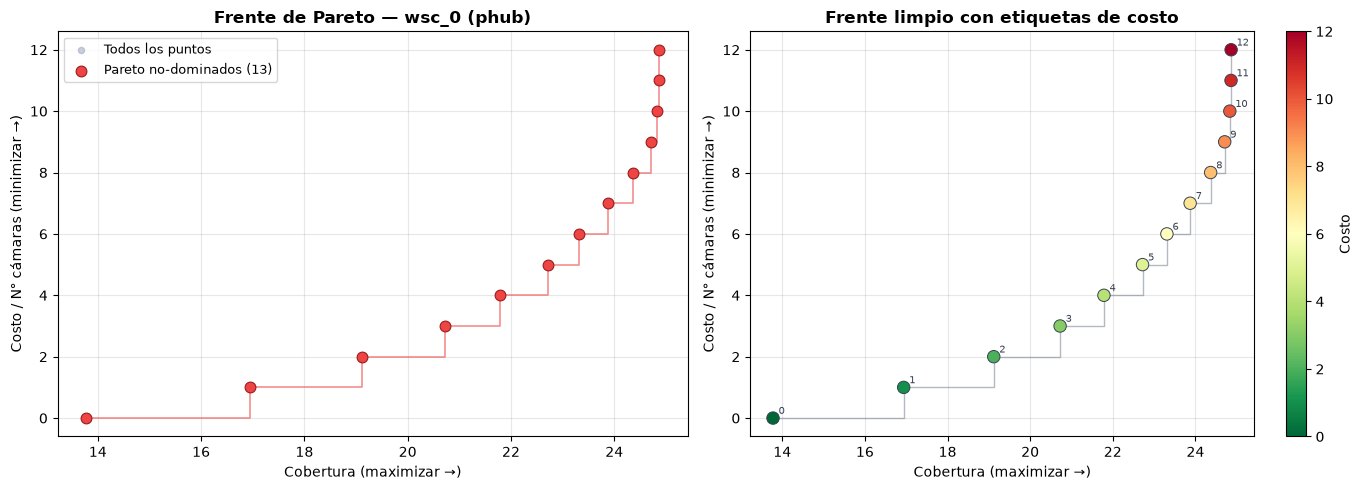

✓ Imagen guardada en images/


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: todos los puntos crudos
ax = axes[0]
ax.scatter(-obj_raw[:, 0], obj_raw[:, 1],
           c='#94a3b8', s=20, alpha=0.5, label='Todos los puntos')
ax.scatter(-obj_clean[:, 0], obj_clean[:, 1],
           c='#ef4444', s=60, zorder=5,
           edgecolors='#991b1b', linewidths=0.8,
           label=f'Pareto no-dominados ({len(obj_clean)})')
# Línea del frente
ax.step(-obj_clean[:, 0], obj_clean[:, 1],
        where='post', color='#ef4444', alpha=0.6, linewidth=1.2)
ax.set_xlabel('Cobertura (maximizar →)')
ax.set_ylabel('Costo / N° cámaras (minimizar →)')
ax.set_title('Frente de Pareto — wsc_0 (phub)', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Panel 2: solo puntos no-dominados
ax2 = axes[1]
scatter = ax2.scatter(-obj_clean[:, 0], obj_clean[:, 1],
                       c=obj_clean[:, 1], cmap='RdYlGn_r',
                       s=80, zorder=5,
                       edgecolors='#374151', linewidths=0.7)
ax2.step(-obj_clean[:, 0], obj_clean[:, 1],
         where='post', color='#6b7280', alpha=0.5, linewidth=1)
plt.colorbar(scatter, ax=ax2, label='Costo')
for i, (f1, f2) in enumerate(obj_clean):
    ax2.annotate(f'{int(f2)}', (-f1, f2),
                 textcoords='offset points', xytext=(4, 3),
                 fontsize=7, color='#374151')
ax2.set_xlabel('Cobertura (maximizar →)')
ax2.set_ylabel('Costo / N° cámaras (minimizar →)')
ax2.set_title('Frente limpio con etiquetas de costo', fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../images/pareto_front_verificacion.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Imagen guardada en images/')

## 3. Procesamiento completo de todos los datasets

In [6]:
def process_dataset(dataset_name, dataset_path):
    """
    Procesa todas las instancias de un dataset.
    Devuelve dict: {instance_name: {'objectives': ndarray, 'solutions': list, 'stats': dict}}
    """
    results = {}

    instance_dirs = sorted([d for d in dataset_path.iterdir() if d.is_dir()])
    print(f'\n── {dataset_name.upper()} ({len(instance_dirs)} instancias) ──')

    for inst_dir in instance_dirs:
        name = inst_dir.name

        # 1. Cargar todos los runs
        obj_raw, sol_raw = load_instance_all_runs(inst_dir)
        if len(obj_raw) == 0:
            print(f'  [SKIP] {name} — sin datos')
            continue

        n_raw = len(obj_raw)

        # 2. Deduplicar por objetivo
        obj_dedup, sol_dedup = deduplicate_by_objectives(obj_raw, sol_raw)
        n_dedup = len(obj_dedup)

        # 3. Filtro de dominancia
        mask_nd = pareto_filter(obj_dedup)
        obj_nd = obj_dedup[mask_nd]
        sol_nd = [sol_dedup[k] for k in range(len(sol_dedup)) if mask_nd[k]]

        # 4. Ordenar por costo ascendente
        order = np.argsort(obj_nd[:, 1])
        obj_final = obj_nd[order]
        sol_final = [sol_nd[k] for k in order]

        results[name] = {
            'objectives': obj_final,
            'solutions' : sol_final,
            'stats': {
                'n_raw'       : n_raw,
                'n_dedup'     : n_dedup,
                'n_pareto'    : len(obj_final),
                'cov_min'     : float(-obj_final[:, 0].max()),
                'cov_max'     : float(-obj_final[:, 0].min()),
                'cost_min'    : int(obj_final[:, 1].min()),
                'cost_max'    : int(obj_final[:, 1].max()),
                'sol_size'    : len(sol_final[0]) if sol_final else 0,
            }
        }

        s = results[name]['stats']
        print(f'  {name[:40]:<40}  '
              f'raw={s["n_raw"]:>4}  dedup={s["n_dedup"]:>4}  '
              f'pareto={s["n_pareto"]:>3}  '
              f'cov=[{s["cov_min"]:.2f},{s["cov_max"]:.2f}]  '
              f'cost=[{s["cost_min"]},{s["cost_max"]}]')

    return results


all_results = {}
for ds_name, ds_path in DATASETS.items():
    all_results[ds_name] = process_dataset(ds_name, ds_path)

total = sum(len(v) for v in all_results.values())
print(f'\n✓ Total instancias procesadas: {total}')


── CLUSTERING (9 instancias) ──
  a1_R1800_pre28                            raw= 505  dedup=  72  pareto= 46  cov=[160.55,487.78]  cost=[0,135]
  a2_R2400_pre9                             raw= 505  dedup=  70  pareto= 42  cov=[130.15,880.63]  cost=[0,149]
  a3_R3050_pre10                            raw= 505  dedup=  88  pareto= 45  cov=[178.42,1242.47]  cost=[0,161]
  dim2_R5150_pre6                           raw= 505  dedup=  79  pareto= 67  cov=[20.32,204.46]  cost=[0,157]
  s1_R28000_pre9                            raw= 505  dedup=  96  pareto= 64  cov=[100.54,817.69]  cost=[0,240]
  s2_R34000_pre28                           raw= 505  dedup=  72  pareto= 49  cov=[343.94,837.85]  cost=[0,219]
  s3_R35000_pre35                           raw= 505  dedup=  52  pareto= 50  cov=[301.45,853.11]  cost=[0,245]
  s4_R32000_pre47                           raw= 505  dedup=  70  pareto= 53  cov=[353.51,827.58]  cost=[0,196]
  unbalance_R1450_pre40                     raw= 505  dedup= 101  paret

## 4. Tabla resumen

In [7]:
rows = []
for ds_name, instances in all_results.items():
    for inst_name, data in instances.items():
        s = data['stats']
        rows.append({
            'Dataset'  : ds_name,
            'Instancia': inst_name,
            'Raw'      : s['n_raw'],
            'Dedup'    : s['n_dedup'],
            'Pareto'   : s['n_pareto'],
            'Cob. min' : round(s['cov_min'], 4),
            'Cob. max' : round(s['cov_max'], 4),
            'Costo min': s['cost_min'],
            'Costo max': s['cost_max'],
            'Sol. size': s['sol_size'],
        })

df = pd.DataFrame(rows)
print(df.to_string(index=False))

print('\n── Resumen por dataset ──')
print(df.groupby('Dataset')[['Raw','Dedup','Pareto']].describe().to_string())

   Dataset             Instancia  Raw  Dedup  Pareto  Cob. min  Cob. max  Costo min  Costo max  Sol. size
clustering        a1_R1800_pre28  505     72      46  160.5509  487.7838          0        135       3000
clustering         a2_R2400_pre9  505     70      42  130.1493  880.6266          0        149       5250
clustering        a3_R3050_pre10  505     88      45  178.4154 1242.4749          0        161       7500
clustering       dim2_R5150_pre6  505     79      67   20.3175  204.4562          0        157       1351
clustering        s1_R28000_pre9  505     96      64  100.5444  817.6872          0        240       5000
clustering       s2_R34000_pre28  505     72      49  343.9426  837.8506          0        219       5000
clustering       s3_R35000_pre35  505     52      50  301.4524  853.1122          0        245       5000
clustering       s4_R32000_pre47  505     70      53  353.5136  827.5832          0        196       5000
clustering unbalance_R1450_pre40  505    101  

## 5. Visualización de todos los frentes

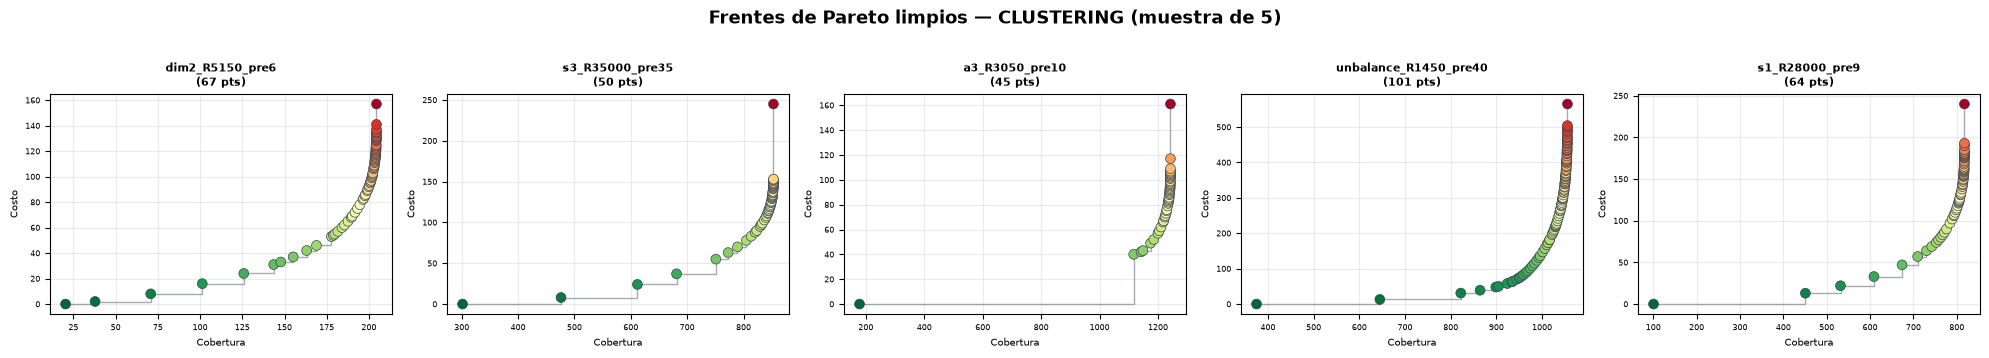

✓ Guardado: images/pareto_fronts_clustering.png


In [8]:
def plot_dataset_fronts(dataset_name, instances, max_cols=5, figsize_per=(4, 3.5)):
    n = len(instances)
    if n == 0:
        return
    ncols = min(n, max_cols)
    nrows = (n + ncols - 1) // ncols
    fw = figsize_per[0] * ncols
    fh = figsize_per[1] * nrows

    fig, axes = plt.subplots(nrows, ncols, figsize=(fw, fh))
    axes = np.array(axes).reshape(-1)  # flatten

    for ax, (inst_name, data) in zip(axes, instances.items()):
        obj = data['objectives']
        cov  = -obj[:, 0]   # cobertura positiva
        cost =  obj[:, 1]

        ax.scatter(cov, cost, c=cost, cmap='RdYlGn_r',
                   s=50, zorder=5,
                   edgecolors='#374151', linewidths=0.5)
        ax.step(cov, cost, where='post',
                color='#6b7280', alpha=0.6, linewidth=1)

        short_name = inst_name.replace('wsc_', '').replace('cam_', '')
        ax.set_title(f'{short_name}\n({len(obj)} pts)',
                     fontsize=8, fontweight='bold')
        ax.set_xlabel('Cobertura', fontsize=7)
        ax.set_ylabel('Costo', fontsize=7)
        ax.tick_params(labelsize=6)
        ax.grid(True, alpha=0.25)

    # Ocultar ejes vacíos
    for ax in axes[len(instances):]:
        ax.set_visible(False)

    fig.suptitle(f'Frentes de Pareto limpios — {dataset_name.upper()} (muestra de {n})',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(f'../images/pareto_fronts_{dataset_name}.png',
                dpi=130, bbox_inches='tight')
    plt.show()
    print(f'✓ Guardado: images/pareto_fronts_{dataset_name}.png')


N_SAMPLE  = 5
rng_plot  = np.random.default_rng(0)

for ds_name, instances in all_results.items():
    keys   = list(instances.keys())
    chosen = rng_plot.choice(keys, size=min(N_SAMPLE, len(keys)), replace=False)
    sample = {k: instances[k] for k in chosen}
    plot_dataset_fronts(ds_name, sample)

## 6. Guardado de resultados limpios

In [9]:
import json

summary_records = []

for ds_name, instances in all_results.items():
    ds_out = OUTPUT_DIR / ds_name
    ds_out.mkdir(parents=True, exist_ok=True)

    for inst_name, data in instances.items():
        inst_out = ds_out / inst_name
        inst_out.mkdir(parents=True, exist_ok=True)

        obj = data['objectives']
        sol = data['solutions']
        s   = data['stats']

        # Guardar objetivos como .npy
        np.save(inst_out / 'objectives.npy', obj)

        # Guardar soluciones como matriz (n_pareto x n_vars)
        sol_matrix = np.stack(sol, axis=0)   # shape (n_pareto, n_vars)
        np.save(inst_out / 'solutions.npy', sol_matrix)

        # Guardar frente limpio también en formato legible
        with open(inst_out / 'pareto_clean.txt', 'w') as f:
            for i, (row_obj, row_sol) in enumerate(zip(obj, sol)):
                f1, f2 = row_obj
                f.write(f'{f1} {int(f2)}\n')
                f.write(' '.join(map(str, row_sol)) + '\n')

        # Registro de metadata
        summary_records.append({
            'dataset'  : ds_name,
            'instance' : inst_name,
            **s
        })

# Guardar resumen global
df_summary = pd.DataFrame(summary_records)
df_summary.to_csv(OUTPUT_DIR / 'summary.csv', index=False)

print('✓ Frentes limpios guardados en frentes_pareto_resultados/clean/')
print(f'  Estructura: clean/<dataset>/<instancia>/')
print(f'              ├── objectives.npy   (n_pareto, 2) float64')
print(f'              ├── solutions.npy    (n_pareto, n_vars) int8')
print(f'              └── pareto_clean.txt (formato legible)')
print(f'  summary.csv  → {len(df_summary)} instancias totales')

✓ Frentes limpios guardados en frentes_pareto_resultados/clean/
  Estructura: clean/<dataset>/<instancia>/
              ├── objectives.npy   (n_pareto, 2) float64
              ├── solutions.npy    (n_pareto, n_vars) int8
              └── pareto_clean.txt (formato legible)
  summary.csv  → 9 instancias totales


## 7. Verificación del guardado

In [10]:
# Cargar y verificar una instancia guardada
test_instance = list(all_results['clustering'].keys())[0]
test_path = OUTPUT_DIR / 'clustering' / test_instance

obj_loaded = np.load(test_path / 'objectives.npy')
sol_loaded = np.load(test_path / 'solutions.npy')

print(f'Instancia de prueba: {test_instance}')
print(f'objectives.npy  → shape {obj_loaded.shape}, dtype {obj_loaded.dtype}')
print(f'solutions.npy   → shape {sol_loaded.shape}, dtype {sol_loaded.dtype}')
print(f'N° cámaras en sol. por punto del frente: {sol_loaded.sum(axis=1).tolist()}')

# Verificar que los vectores de solución coinciden con el costo f2
n_cams_from_obj = obj_loaded[:, 1].astype(int)
n_cams_from_sol = sol_loaded.sum(axis=1)
match = np.all(n_cams_from_obj == n_cams_from_sol)
print(f'\n✓ Consistencia f2 == sum(solución): {match}')
if not match:
    diff = np.where(n_cams_from_obj != n_cams_from_sol)[0]
    print(f'  Discrepancias en índices: {diff}')

Instancia de prueba: a1_R1800_pre28
objectives.npy  → shape (46, 2), dtype float64
solutions.npy   → shape (46, 3000), dtype int8
N° cámaras en sol. por punto del frente: [28, 35, 42, 56, 60, 68, 73, 79, 81, 85, 88, 94, 95, 97, 98, 100, 102, 103, 105, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 133, 134, 135, 163]

✓ Consistencia f2 == sum(solución): False
  Discrepancias en índices: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45]


In [11]:
# Resumen final
print('=' * 60)
print('RESUMEN FINAL')
print('=' * 60)
for ds in ['cdmx', 'clustering', 'phub']:
    if ds not in all_results:
        continue
    inst = all_results[ds]
    pareto_sizes = [d['stats']['n_pareto'] for d in inst.values()]
    raw_sizes    = [d['stats']['n_raw']    for d in inst.values()]
    print(f'\n{ds.upper()}:')
    print(f'  Instancias            : {len(inst)}')
    print(f'  Puntos raw (total)    : {sum(raw_sizes)}')
    print(f'  Puntos Pareto (total) : {sum(pareto_sizes)}')
    print(f'  Tamaño frente — min={min(pareto_sizes)}, max={max(pareto_sizes)}, '
          f'media={np.mean(pareto_sizes):.1f}')

RESUMEN FINAL

CLUSTERING:
  Instancias            : 9
  Puntos raw (total)    : 4545
  Puntos Pareto (total) : 517
  Tamaño frente — min=42, max=101, media=57.4
